
# STEP 1: Import Required Libraries & Set Reproducibility


In [11]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import KFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [12]:
# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# STEP 2: Dataset Extraction & Directory Setup

In [13]:
import os

# Unzip dataset
!unzip -o /content/Drive.zip -d /content/

# Base directory
BASE_DIR = "/content/archive/DRIVE"

# Warn if base directory missing
if not os.path.exists(BASE_DIR):
    print(f"Warning: The expected base directory '{BASE_DIR}' was not found after unzipping.")

# Paths
TRAIN_IMG_DIR  = os.path.join(BASE_DIR, "training", "images")
TRAIN_MASK_DIR = os.path.join(BASE_DIR, "training", "mask")
TEST_IMG_DIR   = os.path.join(BASE_DIR, "test", "images")
TEST_MASK_DIR  = os.path.join(BASE_DIR, "test", "mask")

# Print paths
print(f"BASE_DIR set to: {BASE_DIR}")
print(f"TRAIN_IMG_DIR set to: {TRAIN_IMG_DIR}")
print(f"TEST_IMG_DIR set to: {TEST_IMG_DIR}")


Archive:  /content/Drive.zip
  inflating: /content/archive/DRIVE/test/images/01_test.tif  
  inflating: /content/archive/DRIVE/test/images/02_test.tif  
  inflating: /content/archive/DRIVE/test/images/03_test.tif  
  inflating: /content/archive/DRIVE/test/images/04_test.tif  
  inflating: /content/archive/DRIVE/test/images/05_test.tif  
  inflating: /content/archive/DRIVE/test/images/06_test.tif  
  inflating: /content/archive/DRIVE/test/images/07_test.tif  
  inflating: /content/archive/DRIVE/test/images/08_test.tif  
  inflating: /content/archive/DRIVE/test/images/09_test.tif  
  inflating: /content/archive/DRIVE/test/images/10_test.tif  
  inflating: /content/archive/DRIVE/test/images/11_test.tif  
  inflating: /content/archive/DRIVE/test/images/12_test.tif  
  inflating: /content/archive/DRIVE/test/images/13_test.tif  
  inflating: /content/archive/DRIVE/test/images/14_test.tif  
  inflating: /content/archive/DRIVE/test/images/15_test.tif  
  inflating: /content/archive/DRIVE/test/

In [14]:
# Verify Image Counts
print("Training Images:", len(os.listdir(TRAIN_IMG_DIR)))
print("Training Masks :", len(os.listdir(TRAIN_MASK_DIR)))

print("Test Images    :", len(os.listdir(TEST_IMG_DIR)))
print("Test Masks     :", len(os.listdir(TEST_MASK_DIR)))

Training Images: 20
Training Masks : 20
Test Images    : 20
Test Masks     : 20


# STEP 3: Visual Inspection of Image & Mask

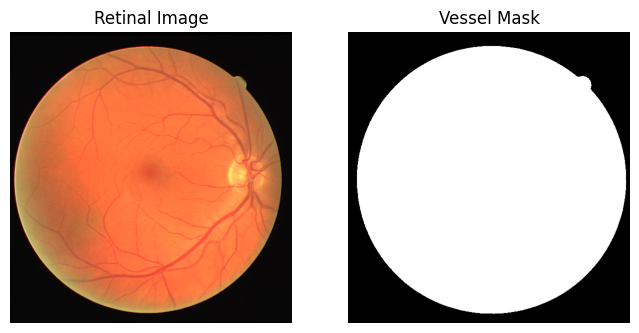

In [15]:
img_name = os.listdir(TRAIN_IMG_DIR)[0]
mask_name = os.listdir(TRAIN_MASK_DIR)[0]
img = cv2.cvtColor(cv2.imread(os.path.join(TRAIN_IMG_DIR, img_name)), cv2.COLOR_BGR2RGB)
mask = cv2.imread(os.path.join(TRAIN_MASK_DIR, mask_name), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Retinal Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Vessel Mask")
plt.axis("off")
plt.show()

# STEP 4: Image Preprocessing

In [16]:
IMG_SIZE = 224
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

# Load images
X_images, masks = [], []

# Load only TRAIN images for proxy label creation
X_images = [preprocess_image(os.path.join(TRAIN_IMG_DIR, img_name))
            for img_name in sorted(os.listdir(TRAIN_IMG_DIR))]
X_images = np.array(X_images)
print("TRAIN Images shape:", X_images.shape)

TRAIN Images shape: (20, 224, 224, 3)


In [17]:
print(os.listdir(TRAIN_IMG_DIR))

['24_training.tif', '36_training.tif', '33_training.tif', '30_training.tif', '38_training.tif', '39_training.tif', '27_training.tif', '21_training.tif', '31_training.tif', '34_training.tif', '28_training.tif', '26_training.tif', '29_training.tif', '35_training.tif', '32_training.tif', '40_training.tif', '22_training.tif', '23_training.tif', '25_training.tif', '37_training.tif']


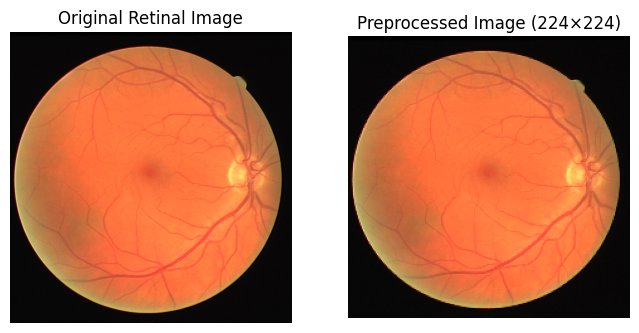

In [18]:
# Get only valid image files
valid_images = [f for f in os.listdir(TRAIN_IMG_DIR)
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))]
img_name = valid_images[0]

original = cv2.imread(os.path.join(TRAIN_IMG_DIR, img_name))
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

processed = preprocess_image(os.path.join(TRAIN_IMG_DIR, img_name))
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original Retinal Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed)
plt.title("Preprocessed Image (224×224)")
plt.axis("off")
plt.show()

# STEP 5: Proxy Label Generation using Vessel Density

In [19]:
# STEP 5: Vessel Density Calculation
def compute_density(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    binary_mask = mask > 0
    return np.sum(binary_mask) / binary_mask.size

In [20]:
vessel_densities = [
    compute_density(os.path.join(TRAIN_MASK_DIR, m))
    for m in sorted(os.listdir(TRAIN_MASK_DIR))
]
median_density = np.median(vessel_densities)

In [21]:
# Load images + assign proxy labels
X_images, labels = [], []
for img_name, mask_name in zip(
    sorted(os.listdir(TRAIN_IMG_DIR)),
    sorted(os.listdir(TRAIN_MASK_DIR))
):
    X_images.append(preprocess_image(os.path.join(TRAIN_IMG_DIR, img_name)))
    density = compute_density(os.path.join(TRAIN_MASK_DIR, mask_name))
    labels.append(0 if density < median_density else 1)
X_images = np.array(X_images)
labels = np.array(labels)
print("Label distribution:", np.bincount(labels))

Label distribution: [10 10]


# STEP 6: Exploratory Data Analysis (EDA)

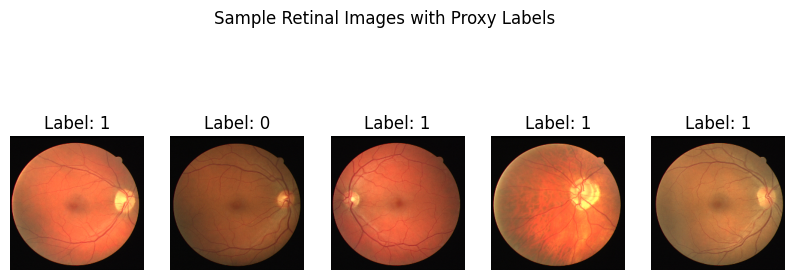

In [22]:
# Visualize random retinal images
plt.figure(figsize=(10,4))
for i in range(5):
    idx = np.random.randint(len(X_images))
    plt.subplot(1,5,i+1)
    plt.imshow(X_images[idx])
    plt.title(f"Label: {labels[idx]}")
    plt.axis('off')
plt.suptitle("Sample Retinal Images with Proxy Labels")
plt.show()

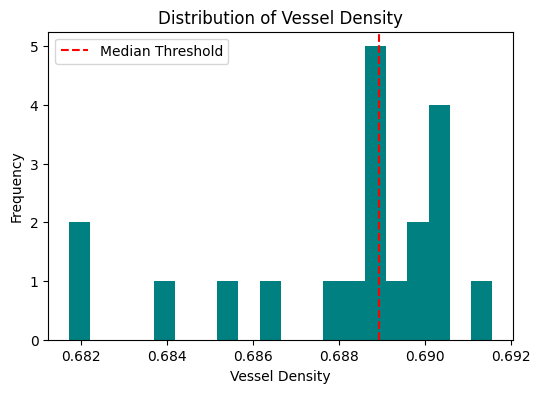

In [23]:
# Vessel density distribution
plt.figure(figsize=(6,4))
plt.hist(vessel_densities, bins=20, color='teal')
plt.axvline(median_density, color='red', linestyle='--', label='Median Threshold')
plt.xlabel("Vessel Density")
plt.ylabel("Frequency")
plt.title("Distribution of Vessel Density")
plt.legend()
plt.show()

# STEP 7: Model Architecture Definitions

In [24]:
# CNN MODEL
IMG_SIZE = 224

def create_cnn_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [25]:
# MobileNetV2 MODEL
def create_mobilenet_model():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(base_model.input, output)
    model.compile(
        optimizer=Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# STEP 8: CNN MODEL (K-Fold Training & Evaluation)

In [26]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.05)

cnn_metrics = []
cnn_models_per_fold = [] # List to store trained CNN models for each fold
X_vals_per_fold = []     # List to store validation sets for each fold

for fold, (train_idx, val_idx) in enumerate(kf.split(X_images)):

    print(f"🔁 CNN – Fold {fold+1}")

    X_train, X_val = X_images[train_idx], X_images[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]

    class_weights = dict(enumerate(
        compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    ))

    cnn_model = create_cnn_model()
    cnn_model.fit(
        datagen.flow(X_train, y_train, batch_size=8, shuffle=False, seed=SEED),
        epochs=25,
        class_weight=class_weights,
        verbose=0
    )

    y_pred = (cnn_model.predict(X_val) > 0.5).astype(int).flatten()

    cnn_metrics.append([
        accuracy_score(y_val, y_pred),
        precision_score(y_val, y_pred),
        recall_score(y_val, y_pred),
        f1_score(y_val, y_pred)
    ])

    cnn_models_per_fold.append(cnn_model) # Store the trained model
    X_vals_per_fold.append(X_val)       # Store the validation data


🔁 CNN – Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
🔁 CNN – Fold 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
🔁 CNN – Fold 3


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
🔁 CNN – Fold 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
🔁 CNN – Fold 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


# STEP 9: CNN MISCLASSIFIED IMAGES

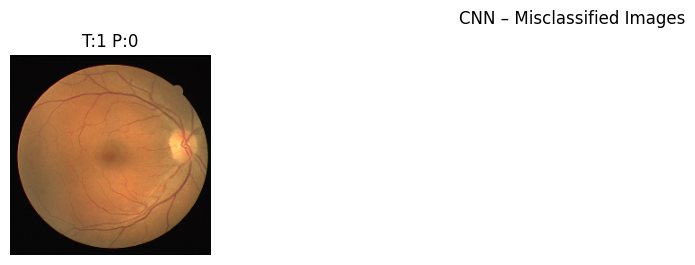

In [27]:
mis_idx = np.where(y_pred != y_val)[0]

if len(mis_idx) == 0:
    print("✅ CNN: No misclassifications found")
else:
    plt.figure(figsize=(15,3))
    for i, idx in enumerate(mis_idx[:5]):
        plt.subplot(1,5,i+1)
        plt.imshow(X_val[idx])
        plt.title(f"T:{y_val[idx]} P:{y_pred[idx]}")
        plt.axis("off")
    plt.suptitle("CNN – Misclassified Images")
    plt.show()


# STEP 10: MobileNetV2 MODEL (K-Fold Training & Evaluation)

In [28]:
mobilenet_metrics = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_images)):
    print(f"\n🔁 MobileNetV2 – Fold {fold+1}")

    X_train, X_val = X_images[train_idx], X_images[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]

    class_weights = dict(enumerate(
        compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    ))
    mobilenet_model = create_mobilenet_model()
    mobilenet_model.fit(
        datagen.flow(X_train, y_train, batch_size=8, shuffle=False, seed=SEED),
        epochs=25,
        class_weight=class_weights,
        verbose=0
    )

    y_pred = (mobilenet_model.predict(X_val) > 0.5).astype(int).flatten()
    mobilenet_metrics.append([
        accuracy_score(y_val, y_pred),
        precision_score(y_val, y_pred),
        recall_score(y_val, y_pred),
        f1_score(y_val, y_pred)
    ])


🔁 MobileNetV2 – Fold 1
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

🔁 MobileNetV2 – Fold 2


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

🔁 MobileNetV2 – Fold 3


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

🔁 MobileNetV2 – Fold 4


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

🔁 MobileNetV2 – Fold 5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


# STEP 11: MobileNetV2 MISCLASSIFIED IMAGES

In [29]:
mis_idx = np.where(y_pred != y_val)[0]

if len(mis_idx) == 0:
    print("✅ MobileNetV2: No misclassifications found")
else:
    plt.figure(figsize=(15,3))
    for i, idx in enumerate(mis_idx[:5]):
        plt.subplot(1,5,i+1)
        plt.imshow(X_val[idx])
        plt.title(f"T:{y_val[idx]} P:{y_pred[idx]}")
        plt.axis("off")
    plt.suptitle("MobileNetV2 – Misclassified Images")
    plt.show()


✅ MobileNetV2: No misclassifications found


In [53]:
import numpy as np

# Convert to numpy arrays
cnn_metrics = np.array(cnn_metrics)
mobilenet_metrics = np.array(mobilenet_metrics)

# Compute averages
cnn_avg = cnn_metrics.mean(axis=0)
mobilenet_avg = mobilenet_metrics.mean(axis=0)

def print_kfold_results(model_name, metrics):
    print(f"🔹 {model_name} Performance (5-Fold CV)")
    print("Accuracy :", metrics[0])
    print("Precision:", metrics[1])
    print("Recall   :", metrics[2])
    print("F1-score :", metrics[3])
    print()

# Print results
print_kfold_results("Lightweight CNN", cnn_avg)
print_kfold_results("MobileNetV2", mobilenet_avg)

🔹 Lightweight CNN Performance (5-Fold CV)
Accuracy : 0.6
Precision: 0.6333333333333333
Recall   : 0.85
F1-score : 0.638095238095238

🔹 MobileNetV2 Performance (5-Fold CV)
Accuracy : 0.55
Precision: 0.5333333333333333
Recall   : 1.0
F1-score : 0.6533333333333333



# STEP 12: Grad-CAM For Both Models


=== Grad-CAM Visualization for MobileNetV2 Model ===

Using layer: block_16_project_BN


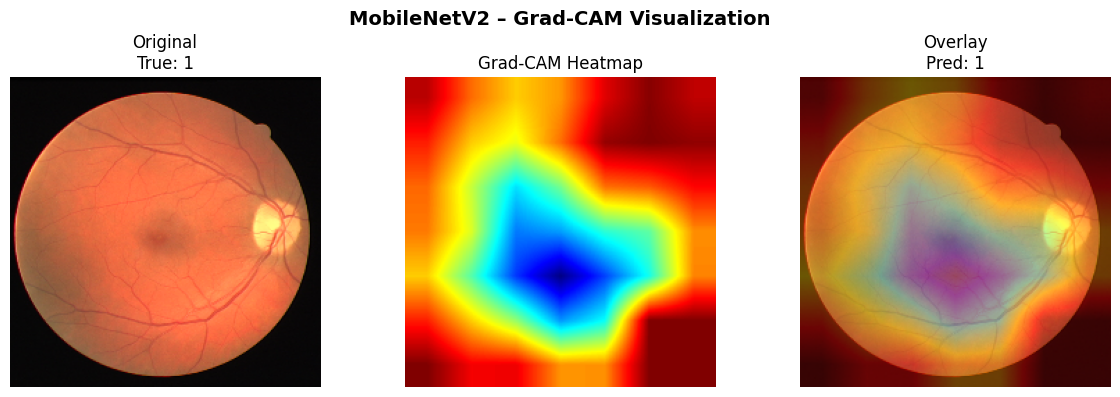


=== Grad-CAM for Multiple Samples ===

Using layer: block_16_project_BN
Using layer: block_16_project_BN
Using layer: block_16_project_BN
Using layer: block_16_project_BN


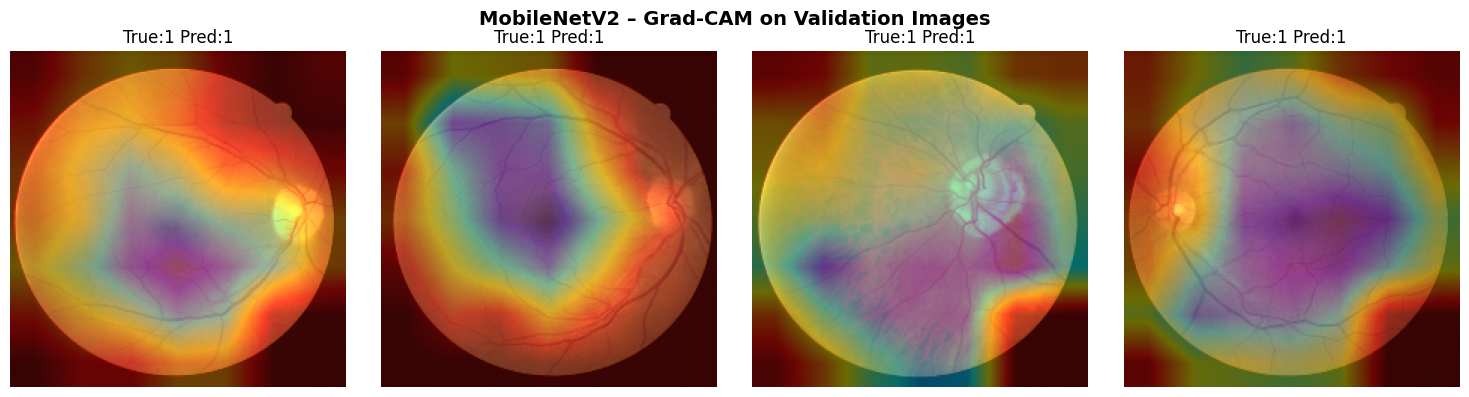

In [51]:
# STEP 12A: Grad-CAM for MobileNetV2
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Grad-CAM Function
def make_gradcam_heatmap(img_array, model, layer="block_16_project_BN"):
    print(f"Using layer: {layer}")

    grad_model = tf.keras.Model(
        model.input,
        [model.get_layer(layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(1, 2))

    heatmap = tf.reduce_sum(conv_out * weights[:, None, None, :], axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)

    return heatmap[0].numpy()


# Single Image Visualization
print("\n=== Grad-CAM Visualization for MobileNetV2 Model ===\n")

idx = 0
img = X_val[idx]

y_pred_single = (mobilenet_model.predict(
    img[None], verbose=0) > 0.5).astype(int)[0, 0]

heatmap = make_gradcam_heatmap(img[None], mobilenet_model)

heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

overlay = cv2.addWeighted(
    (img * 255).astype(np.uint8), 0.6,
    heatmap, 0.4, 0
)

plt.figure(figsize=(12, 4))
for i, (title, im) in enumerate([
    (f"Original\nTrue: {y_val[idx]}", img),
    ("Grad-CAM Heatmap", heatmap),
    (f"Overlay\nPred: {y_pred_single}", overlay)
]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(im)
    plt.title(title)
    plt.axis("off")

plt.suptitle("MobileNetV2 – Grad-CAM Visualization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# Multiple Samples
print("\n=== Grad-CAM for Multiple Samples ===\n")

n = min(4, len(X_val))
plt.figure(figsize=(15, 4))

for i in range(n):
    img = X_val[i]
    pred = (mobilenet_model.predict(img[None], verbose=0) > 0.5).astype(int)[0, 0]

    heatmap = make_gradcam_heatmap(img[None], mobilenet_model)
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(
        (img * 255).astype(np.uint8), 0.6,
        heatmap, 0.4, 0
    )

    plt.subplot(1, n, i + 1)
    plt.imshow(overlay)
    plt.title(f"True:{y_val[i]} Pred:{pred}")
    plt.axis("off")

plt.suptitle("MobileNetV2 – Grad-CAM on Validation Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


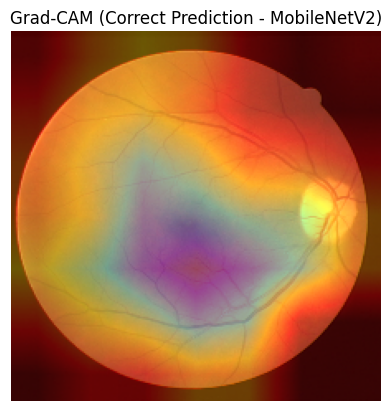

In [37]:
def make_gradcam_heatmap(img, model, last_conv, idx=None):
    grad_model = tf.keras.Model(
        model.input, [model.get_layer(last_conv).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img)
        idx = tf.argmax(preds[0]) if idx is None else idx
        loss = preds[:, idx]

    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(conv_out[0] @ weights[..., None])
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# Sample image
img = X_val[0]
last_conv = "block_16_project_BN"

# Generate Grad-CAM
heatmap = make_gradcam_heatmap(
    np.expand_dims(img, 0), mobilenet_model, last_conv
)

# Resize & colorize
heatmap = cv2.applyColorMap(
    np.uint8(255 * cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))),
    cv2.COLORMAP_JET
)

# Overlay
overlay = cv2.addWeighted(
    (img * 255).astype(np.uint8), 0.6, heatmap, 0.4, 0
)

plt.imshow(overlay)
plt.title("Grad-CAM (Correct Prediction - MobileNetV2)")
plt.axis("off")
plt.show()


In [42]:
_ = cnn_model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)))


=== Grad-CAM Visualization for CNN Model ===

Using layer: conv2d_14 at index 4


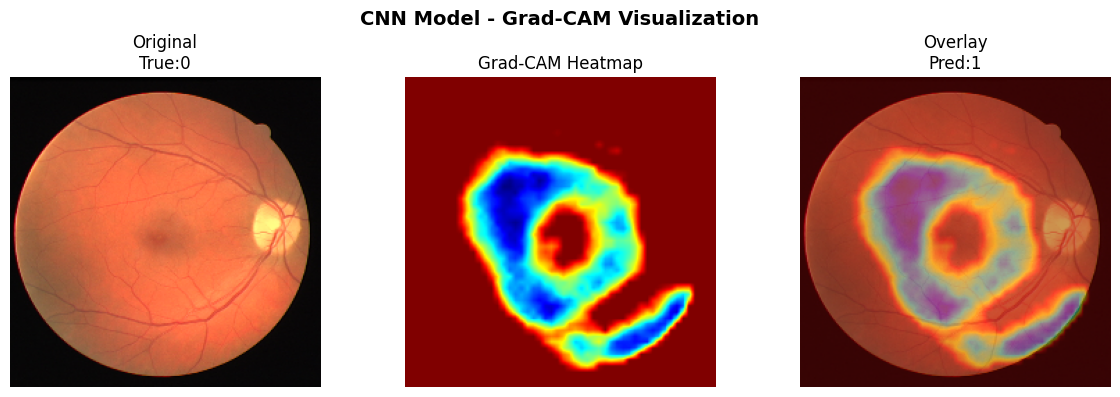


=== Grad-CAM for Multiple Samples ===

Using layer: conv2d_14 at index 4
Using layer: conv2d_14 at index 4
Using layer: conv2d_14 at index 4
Using layer: conv2d_14 at index 4


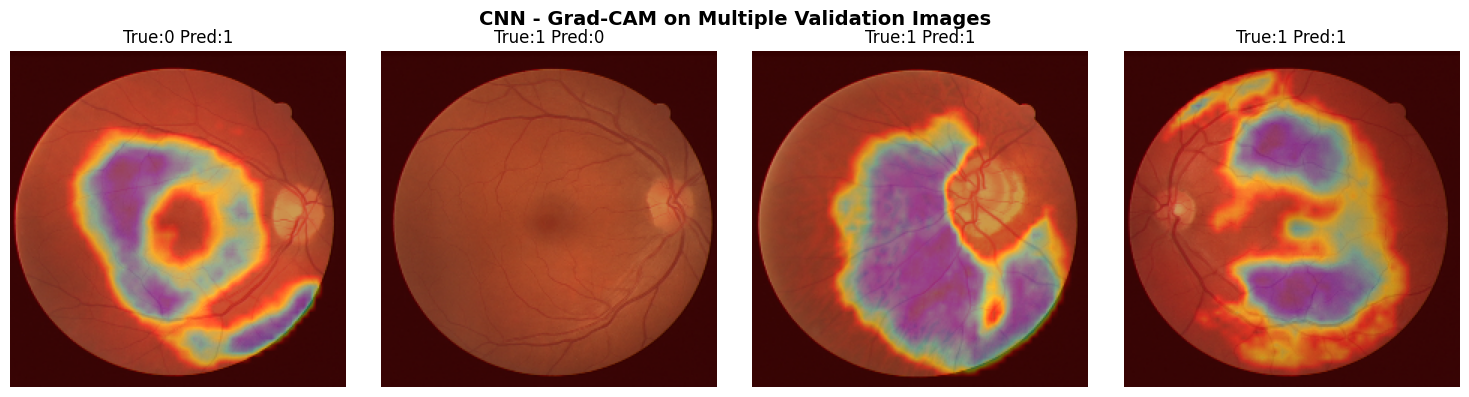

In [49]:
# STEP 12B: Grad-CAM for CNN
import tensorflow as tf, numpy as np, cv2, matplotlib.pyplot as plt

def make_gradcam_heatmap_cnn(img, model):
    i = max(j for j,l in enumerate(model.layers)
            if isinstance(l, tf.keras.layers.Conv2D))
    print(f"Using layer: {model.layers[i].name} at index {i}")

    with tf.GradientTape() as t:
        x = tf.cast(img, tf.float32)
        for l in model.layers[:i+1]: x = l(x)
        conv = x; t.watch(conv)
        for l in model.layers[i+1:]: x = l(x)
        pred = x[0,0]

    w = tf.reduce_mean(t.gradient(pred, conv), axis=(0,1,2)).numpy()
    cam = np.mean(conv[0].numpy() * w, axis=-1)
    cam = np.maximum(cam, 0)
    return cam / cam.max() if cam.max() else cam


print("\n=== Grad-CAM Visualization for CNN Model ===\n")

cnn_model = cnn_models_per_fold[-1]
X_val = X_vals_per_fold[-1]

img = X_val[0]
pred = (cnn_model.predict(img[None], verbose=0) > .5).astype(int)[0,0]
cam = make_gradcam_heatmap_cnn(img[None], cnn_model)

cam = cv2.applyColorMap(
    np.uint8(255 * cv2.resize(cam, (IMG_SIZE, IMG_SIZE))),
    cv2.COLORMAP_JET
)
overlay = cv2.addWeighted((img*255).astype(np.uint8), .6, cam, .4, 0)

plt.figure(figsize=(12,4))
for i,(im,t) in enumerate([
    (img,f"Original\nTrue:{labels[0]}"),
    (cam,"Grad-CAM Heatmap"),
    (overlay,f"Overlay\nPred:{pred}")
]):
    plt.subplot(1,3,i+1); plt.imshow(im); plt.title(t); plt.axis("off")
plt.suptitle("CNN Model - Grad-CAM Visualization", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


print("\n=== Grad-CAM for Multiple Samples ===\n")
n = min(4,len(X_val)); plt.figure(figsize=(15,4))

for i in range(n):
    img = X_val[i]
    pred = (cnn_model.predict(img[None], verbose=0) > .5).astype(int)[0,0]
    cam = make_gradcam_heatmap_cnn(img[None], cnn_model)
    cam = cv2.applyColorMap(
        np.uint8(255 * cv2.resize(cam,(IMG_SIZE,IMG_SIZE))),
        cv2.COLORMAP_JET
    )
    plt.subplot(1,n,i+1)
    plt.imshow(cv2.addWeighted((img*255).astype(np.uint8),.6,cam,.4,0))
    plt.title(f"True:{labels[i]} Pred:{pred}")
    plt.axis("off")

plt.suptitle("CNN - Grad-CAM on Multiple Validation Images",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


# STEP 13: Final Comparison Table

In [52]:
import pandas as pd
cnn_avg = np.mean(cnn_metrics, axis=0)
mobilenet_avg = np.mean(mobilenet_metrics, axis=0)
df = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2"],
    "Accuracy": [cnn_avg[0], mobilenet_avg[0]],
    "Precision": [cnn_avg[1], mobilenet_avg[1]],
    "Recall": [cnn_avg[2], mobilenet_avg[2]],
    "F1-score": [cnn_avg[3], mobilenet_avg[3]]
})
print(df)

         Model  Accuracy  Precision  Recall  F1-score
0          CNN      0.60   0.633333    0.85  0.638095
1  MobileNetV2      0.55   0.533333    1.00  0.653333


In [40]:
import numpy as np

# Convert to numpy arrays
cnn_metrics = np.array(cnn_metrics)
mobilenet_metrics = np.array(mobilenet_metrics)

# Compute averages
cnn_avg = cnn_metrics.mean(axis=0)
mobilenet_avg = mobilenet_metrics.mean(axis=0)

def print_kfold_results(model_name, metrics):
    print(f"🔹 {model_name} Performance (5-Fold CV)")
    print("Accuracy :", metrics[0])
    print("Precision:", metrics[1])
    print("Recall   :", metrics[2])
    print("F1-score :", metrics[3])
    print()

# Print results
print_kfold_results("Lightweight CNN", cnn_avg)
print_kfold_results("MobileNetV2", mobilenet_avg)

🔹 Lightweight CNN Performance (5-Fold CV)
Accuracy : 0.6
Precision: 0.6333333333333333
Recall   : 0.85
F1-score : 0.638095238095238

🔹 MobileNetV2 Performance (5-Fold CV)
Accuracy : 0.55
Precision: 0.5333333333333333
Recall   : 1.0
F1-score : 0.6533333333333333



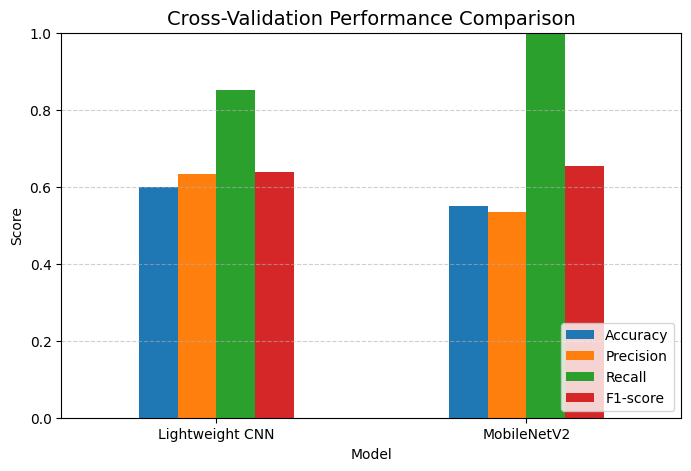

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create DataFrame from k-fold averages
df = pd.DataFrame({
    "Model": ["Lightweight CNN", "MobileNetV2"],
    "Accuracy": [cnn_avg[0], mobilenet_avg[0]],
    "Precision": [cnn_avg[1], mobilenet_avg[1]],
    "Recall": [cnn_avg[2], mobilenet_avg[2]],
    "F1-score": [cnn_avg[3], mobilenet_avg[3]]
})

df.set_index("Model", inplace=True)

# Plot
df.plot(kind="bar", figsize=(8,5))
plt.title("Cross-Validation Performance Comparison", fontsize=14)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(loc="lower right")
plt.show()
